Panel: 703,087 x 59
Treated (HH) units: 11
Donor pool size:    66
Pre-period:  2019-01-01 to 2020-03-20
Post-period: 2020-03-21 to 2020-12-31
Wide matrix: 731 days × 77 communities
Pre-period days:  445
Post-period days: 286
Fitting SCM for each treated HH community...
Unit         Pre-RMSE        ATT Top donor       top weight
------------------------------------------------------------
  7             1.346     -2.859 19                   0.166
  8             3.574    -10.869 25                   0.650
  23            2.134     -0.492 25                   0.216
  24            2.042     -1.672 22                   0.289
  26            2.205     -1.502 77                   0.329
  27            1.584     -0.914 66                   0.123
  28            2.995     -4.442 25                   0.308
  29            2.316     -2.292 43                   0.317
  32            5.281    -10.597 25                   0.466
  69            1.715     -0.129 53                   0.316
  71     

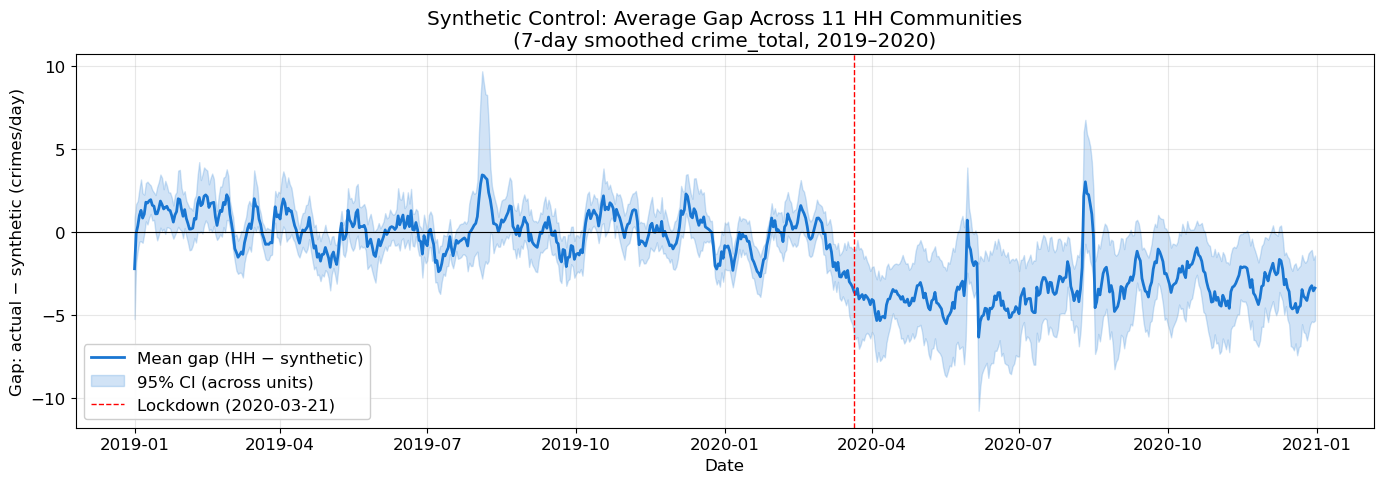

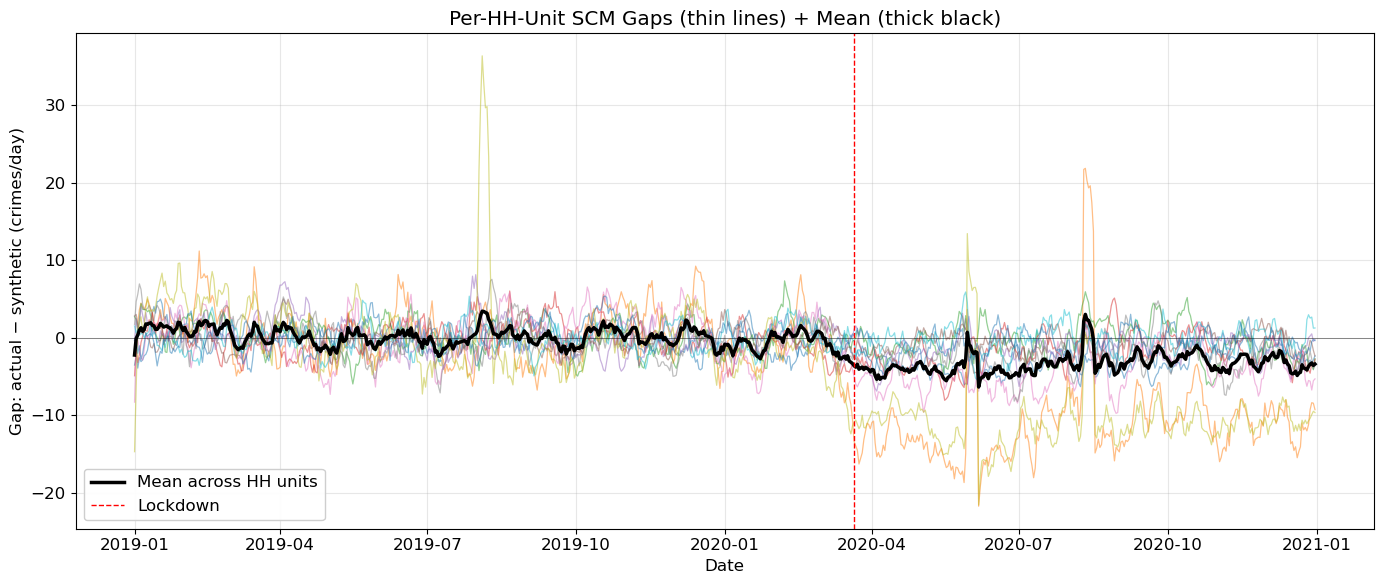

Running placebo on 50 donor units...
  10/50 placebo fits done
  20/50 placebo fits done
  30/50 placebo fits done
  40/50 placebo fits done
  50/50 placebo fits done

Completed 50 placebo fits
Placebos retained after pre-RMSE filter: 50/50
PERMUTATION INFERENCE
Aggregate ATT:                      -3.340
Placebo ATT distribution:
  Mean:                            -1.216
  SD:                               2.852
  5%ile / 95%ile:                -4.643 / +0.995

Two-sided permutation p-value:   0.2600


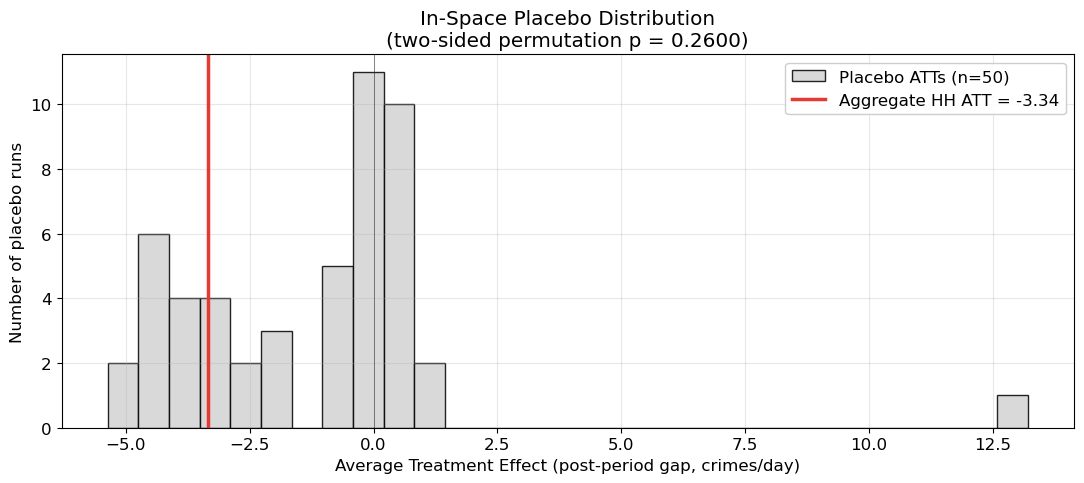

FINAL COMPARISON: NB05 DID vs NB05B SCM

Method                                  Estimate            Inference
----------------------------------------------------------------------
NB05 DID (Community FE)                   -6.047   p < 0.0001 (clust)
NB05B SCM (aggregate ATT)                 -3.340   p = 0.2600 (perm.)


In [1]:
# Synthetic Control Method

# Synthetic control (Abadie et al. 2010) as an alternative to NB05's DID.
# Treated: 11 HH communities. Donor pool: 66 non-HH communities.
# Pre-period: 2019-01-01 to 2020-03-20. Post-period: 2020-03-21 to 2020-12-31.
# Inference: in-space placebo permutation (50 donors).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb05b'
os.makedirs(FIGURE_DIR, exist_ok=True)

panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

# 1. Sample construction
# Restrict to 2019-2020 daily panel, identify treated and donor units.

TREATMENT_DATE = pd.Timestamp('2020-03-21')
PRE_START      = pd.Timestamp('2019-01-01')
POST_END       = pd.Timestamp('2020-12-31')

scm_panel = panel[
    (panel['date'] >= PRE_START) & (panel['date'] <= POST_END)
].copy()

# Treated = HH; donors = everyone else (NOT just LL)
treated_units = (scm_panel.loc[scm_panel['lisa_cluster'] == 'HH',
                                'community_area']
                          .unique().tolist())
donor_units   = (scm_panel.loc[scm_panel['lisa_cluster'] != 'HH',
                                'community_area']
                          .unique().tolist())

print(f"Treated (HH) units: {len(treated_units)}")
print(f"Donor pool size:    {len(donor_units)}")
print(f"Pre-period:  {PRE_START.date()} to {(TREATMENT_DATE - pd.Timedelta(days=1)).date()}")
print(f"Post-period: {TREATMENT_DATE.date()} to {POST_END.date()}")

# 2. Reshape to wide format

# SCM works on a (time × unit) matrix of outcomes. We pivot to that shape 
# once, and reuse it for every treated unit.

Y_wide = scm_panel.pivot_table(
    index='date', columns='community_area', values='crime_total', aggfunc='sum'
).sort_index()

Y_smooth = Y_wide.rolling(window=7, min_periods=1).mean()

print(f"Wide matrix: {Y_smooth.shape[0]} days × {Y_smooth.shape[1]} communities")

pre_mask  = Y_smooth.index <  TREATMENT_DATE
post_mask = Y_smooth.index >= TREATMENT_DATE
n_pre  = pre_mask.sum()
n_post = post_mask.sum()
print(f"Pre-period days:  {n_pre}")
print(f"Post-period days: {n_post}")

# 3. SCM solver
# For each treated unit i with pre-period outcome vector y_i (length n_pre), 
# find weights w over donor units that minimize

#     || y_i  −  Y_donor · w ||²
#
# subject to:  w_j ≥ 0 for all j,  Σ w_j = 1.
#
# This is a small constrained quadratic programme. We use scipy's SLSQP with 
# explicit non-negativity bounds and a sum-to-one equality constraint.

def fit_scm(y_treated_pre, Y_donor_pre):
    """
    y_treated_pre : (n_pre,) array of treated unit's pre-period outcomes
    Y_donor_pre   : (n_pre, n_donor) array of donor units' pre-period outcomes
    Returns: weights (n_donor,)
    """
    n_donor = Y_donor_pre.shape[1]
    w0 = np.ones(n_donor) / n_donor  # uniform start
    
    def loss(w):
        resid = y_treated_pre - Y_donor_pre @ w
        return np.sum(resid**2)
    
    bounds = [(0.0, 1.0)] * n_donor
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    
    res = minimize(loss, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-10})
    return res.x

# 4. Apply SCM to each treated HH unit

results_scm = []  # one record per treated HH unit

print("Fitting SCM for each treated HH community...")
print(f"{'Unit':<10s} {'Pre-RMSE':>10s} {'ATT':>10s} {'Top donor':<15s} {'top weight':>10s}")
print("-" * 60)

for unit in treated_units:
    if unit not in Y_smooth.columns:
        continue
    
    # Build matrices for this fit
    y_treated_full  = Y_smooth[unit].values
    donor_cols      = [d for d in donor_units if d in Y_smooth.columns]
    Y_donor_full    = Y_smooth[donor_cols].values
    
    y_treated_pre   = y_treated_full[pre_mask]
    Y_donor_pre     = Y_donor_full[pre_mask, :]
    
    # Skip if any donor has NaN in pre-period (shouldn't happen, but safe)
    if np.isnan(Y_donor_pre).any() or np.isnan(y_treated_pre).any():
        print(f"  {unit}: NaN in pre-period, skipping")
        continue
    
    # Solve SCM
    w = fit_scm(y_treated_pre, Y_donor_pre)
    
    # Compute synthetic outcome over full period
    y_synth_full = Y_donor_full @ w
    
    # Pre-period fit quality
    pre_rmse = np.sqrt(np.mean((y_treated_pre - y_synth_full[pre_mask])**2))
    
    # Treatment effect = average post-period gap
    gap = y_treated_full - y_synth_full
    att = np.mean(gap[post_mask])
    
    # Identify top donor
    top_idx = np.argmax(w)
    top_donor = donor_cols[top_idx]
    top_weight = w[top_idx]
    
    results_scm.append({
        'unit':       unit,
        'pre_rmse':   pre_rmse,
        'att':        att,
        'gap':        gap,        # full time series of gap
        'y_treated':  y_treated_full,
        'y_synth':    y_synth_full,
        'weights':    dict(zip(donor_cols, w)),
        'top_donor':  top_donor,
        'top_weight': top_weight,
    })
    
    print(f"  {unit:<8s} {pre_rmse:>10.3f} {att:>+10.3f} {top_donor:<15s} {top_weight:>10.3f}")

print(f"\nSCM fitted for {len(results_scm)} treated units.")

# 5. Aggregate ATT
atts = np.array([r['att'] for r in results_scm])
agg_att = np.mean(atts)
agg_att_sd = np.std(atts, ddof=1)
agg_att_se = agg_att_sd / np.sqrt(len(atts))   # SE of the mean across units

print("="*60)
print("AGGREGATE ATT (Synthetic Control)")
print("="*60)
print(f"Number of treated HH units:    {len(atts)}")
print(f"Mean ATT (post-period gap):    {agg_att:>+8.3f}")
print(f"Across-unit SD:                {agg_att_sd:>8.3f}")
print(f"SE of the mean:                {agg_att_se:>8.3f}")
print(f"Min / Max unit-level ATT:      {atts.min():+.3f} / {atts.max():+.3f}")
print(f"\nFor comparison, NB05 DID coefficient:  -6.047")
print("="*60)

# 6. Aggregate gap plot
# Average gap (treated − synthetic) across all 11 HH units, plotted over time.
# A clear post-March-2020 drop confirms the pattern.

gap_matrix = np.vstack([r['gap'] for r in results_scm])  # (11, n_days)
mean_gap = gap_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
dates = Y_smooth.index
ax.plot(dates, mean_gap, color='#1976D2', lw=2, label='Mean gap (HH − synthetic)')
ax.fill_between(dates,
                mean_gap - 1.96 * gap_matrix.std(axis=0)/np.sqrt(len(atts)),
                mean_gap + 1.96 * gap_matrix.std(axis=0)/np.sqrt(len(atts)),
                color='#1976D2', alpha=0.2, label='95% CI (across units)')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(TREATMENT_DATE, color='red', lw=1, linestyle='--', label='Lockdown (2020-03-21)')
ax.set_xlabel('Date')
ax.set_ylabel('Gap: actual − synthetic (crimes/day)')
ax.set_title('Synthetic Control: Average Gap Across 11 HH Communities\n'
             '(7-day smoothed crime_total, 2019–2020)')
ax.legend(loc='lower left', framealpha=0.95)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_aggregate_gap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 7. Per-unit gap plot

fig, ax = plt.subplots(figsize=(14, 6))
for r in results_scm:
    ax.plot(dates, r['gap'], lw=0.9, alpha=0.5)
ax.plot(dates, mean_gap, color='black', lw=2.5, label='Mean across HH units')
ax.axhline(0, color='black', lw=0.6, alpha=0.5)
ax.axvline(TREATMENT_DATE, color='red', lw=1, linestyle='--', label='Lockdown')
ax.set_xlabel('Date')
ax.set_ylabel('Gap: actual − synthetic (crimes/day)')
ax.set_title('Per-HH-Unit SCM Gaps (thin lines) + Mean (thick black)')
ax.legend(loc='lower left', framealpha=0.95)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_per_unit_gaps.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 8. In-space placebo inference

N_PLACEBO_MAX = 50
placebo_donors = donor_units[:N_PLACEBO_MAX]
print(f"Running placebo on {len(placebo_donors)} donor units...")

placebo_atts     = []
placebo_pre_rmse = []
placebo_gaps     = []

for j, fake_treated in enumerate(placebo_donors):
    if fake_treated not in Y_smooth.columns:
        continue
    
    # Use all OTHER non-HH units as donor pool for this placebo run
    fake_donors = [d for d in donor_units if d != fake_treated and d in Y_smooth.columns]
    if len(fake_donors) < 5:
        continue
    
    y_treated_full  = Y_smooth[fake_treated].values
    Y_donor_full    = Y_smooth[fake_donors].values
    
    y_treated_pre   = y_treated_full[pre_mask]
    Y_donor_pre     = Y_donor_full[pre_mask, :]
    
    if np.isnan(Y_donor_pre).any() or np.isnan(y_treated_pre).any():
        continue
    
    w = fit_scm(y_treated_pre, Y_donor_pre)
    y_synth_full = Y_donor_full @ w
    
    pre_rmse = np.sqrt(np.mean((y_treated_pre - y_synth_full[pre_mask])**2))
    gap = y_treated_full - y_synth_full
    att = np.mean(gap[post_mask])
    
    placebo_atts.append(att)
    placebo_pre_rmse.append(pre_rmse)
    placebo_gaps.append(gap)
    
    if (j + 1) % 10 == 0:
        print(f"  {j+1}/{len(placebo_donors)} placebo fits done")

placebo_atts     = np.array(placebo_atts)
placebo_pre_rmse = np.array(placebo_pre_rmse)
print(f"\nCompleted {len(placebo_atts)} placebo fits")

# Filter placebos with very poor pre-fit (Abadie's recommendation: drop 
# placebos whose pre-RMSE is much larger than the treated unit's, since 
# their post-period 'effects' are then artefacts of bad pre-fit)
treated_max_rmse = max(r['pre_rmse'] for r in results_scm)
keep_placebo = placebo_pre_rmse <= 5 * treated_max_rmse
placebo_atts_filt = placebo_atts[keep_placebo]
print(f"Placebos retained after pre-RMSE filter: {keep_placebo.sum()}/{len(keep_placebo)}")

# 9. Empirical p-value
# Two-sided permutation p-value: fraction of placebo |ATT|s as extreme or 
# more extreme than the absolute value of the aggregate ATT.

abs_agg = abs(agg_att)
p_two_sided = np.mean(np.abs(placebo_atts_filt) >= abs_agg)

print("="*60)
print("PERMUTATION INFERENCE")
print("="*60)
print(f"Aggregate ATT:                    {agg_att:>+8.3f}")
print(f"Placebo ATT distribution:")
print(f"  Mean:                          {placebo_atts_filt.mean():>+8.3f}")
print(f"  SD:                            {placebo_atts_filt.std():>8.3f}")
print(f"  5%ile / 95%ile:                {np.percentile(placebo_atts_filt, 5):+.3f} "
      f"/ {np.percentile(placebo_atts_filt, 95):+.3f}")
print(f"\nTwo-sided permutation p-value:   {p_two_sided:.4f}")
print("="*60)

# 10. Inference plot
# Histogram of placebo ATTs with the aggregate ATT marked.

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(placebo_atts_filt, bins=30, color='lightgray',
        edgecolor='black', alpha=0.85, label=f'Placebo ATTs (n={len(placebo_atts_filt)})')
ax.axvline(agg_att, color='#E53935', lw=2.5,
           label=f'Aggregate HH ATT = {agg_att:.2f}')
ax.axvline(-abs_agg, color='#E53935', lw=1, linestyle=':')
ax.axvline(0, color='black', lw=0.6, alpha=0.5)
ax.set_xlabel('Average Treatment Effect (post-period gap, crimes/day)')
ax.set_ylabel('Number of placebo runs')
ax.set_title(f'In-Space Placebo Distribution\n'
             f'(two-sided permutation p = {p_two_sided:.4f})')
ax.legend(loc='upper right', framealpha=0.95)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '03_placebo_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 11. Comparison with NB05 DID
# A side-by-side numerical comparison.

print("="*70)
print("FINAL COMPARISON: NB05 DID vs NB05B SCM")
print("="*70)
print(f"\n{'Method':<35s} {'Estimate':>12s} {'Inference':>20s}")
print("-"*70)
print(f"{'NB05 DID (Community FE)':<35s} {-6.047:>+12.3f} {'p < 0.0001 (clust)':>20s}")
print(f"{'NB05B SCM (aggregate ATT)':<35s} {agg_att:>+12.3f} {'p = '+f'{p_two_sided:.4f}'+' (perm.)':>20s}")
print("="*70)

